In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error, accuracy_score, confusion_matrix, classification_report,r2_score

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import joblib

import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
pd.set_option('display.max_columns',None)

In [2]:
df = pd.read_csv('/Users/alfiyaansari/Desktop/Project/HDHI_Admission_data.csv')

In [3]:
df.head()

,SNO,MRD No.,D.O.A,D.O.D,AGE,GENDER,RURAL,TYPE OF ADMISSION-EMERGENCY/OPD,month year,DURATION OF STAY,duration of intensive unit stay,OUTCOME,SMOKING,ALCOHOL,DM,HTN,CAD,PRIOR CMP,CKD,HB,TLC,PLATELETS,GLUCOSE,UREA,CREATININE,BNP,RAISED CARDIAC ENZYMES,EF,SEVERE ANAEMIA,ANAEMIA,STABLE ANGINA,ACS,STEMI,ATYPICAL CHEST PAIN,HEART FAILURE,HFREF,HFNEF,VALVULAR,CHB,SSS,AKI,CVA INFRACT,CVA BLEED,AF,VT,PSVT,CONGENITAL,UTI,NEURO CARDIOGENIC SYNCOPE,ORTHOSTATIC,INFECTIVE ENDOCARDITIS,DVT,CARDIOGENIC SHOCK,SHOCK,PULMONARY EMBOLISM,CHEST INFECTION
0,1,234735,4/1/2017,4/3/2017,81,M,R,E,Apr-17,3,2,DISCHARGE,0,0,1,0,0,0,0,9.5,16.1,337,80,34,0.9,1880,1,35,0,1,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,234696,4/1/2017,4/5/2017,65,M,R,E,Apr-17,5,2,DISCHARGE,0,1,0,1,1,0,0,13.7,9,149,112,18,0.9,NaN,0,42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,3,234882,4/1/2017,4/3/2017,53,M,U,E,Apr-17,3,3,DISCHARGE,0,0,1,0,1,0,0,10.6,14.7,329,187,93,2.3,210,0,NaN,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,234635,4/1/2017,4/8/2017,67,F,U,E,Apr-17,8,6,DISCHARGE,0,0,0,1,1,0,0,12.8,9.9,286,130,27,0.6,NaN,0,42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5,234486,4/1/2017,4/23/2017,60,F,U,E,Apr-17,23,9,DISCHARGE,0,0,0,1,0,1,0,13.6,9.1,26,144,55,1.25,1840,0,16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(15757, 56)

In [5]:
columns_to_keep = [ "D.O.A", "AGE", "GENDER", "RURAL", "TYPE OF ADMISSION-EMERGENCY/OPD", "DURATION OF STAY",
                   "duration of intensive unit stay", "OUTCOME","SMOKING ", "ALCOHOL", "DM", "HTN", 
                   "CKD", "HEART FAILURE", "ACS", "SHOCK", "CHEST INFECTION" ]

In [6]:
df = df[columns_to_keep]

In [7]:
df.columns

Index(['D.O.A', 'AGE', 'GENDER', 'RURAL', 'TYPE OF ADMISSION-EMERGENCY/OPD',
       'DURATION OF STAY', 'duration of intensive unit stay', 'OUTCOME',
       'SMOKING ', 'ALCOHOL', 'DM', 'HTN', 'CKD', 'HEART FAILURE', 'ACS',
       'SHOCK', 'CHEST INFECTION'],
      dtype='object')

In [8]:
rename_columns = {
    "D.O.A": "admission_date","month year": "month_year","AGE": "age","GENDER": "gender",
    "RURAL": "is_rural","TYPE OF ADMISSION-EMERGENCY/OPD": "admission_type","DURATION OF STAY": "length_of_stay",
    "duration of intensive unit stay": "icu_stay_days","OUTCOME": "patient_outcome","SMOKING ": "is_smoker",
    "ALCOHOL": "uses_alcohol","DM": "has_diabetes","HTN": "has_hypertension",
    "CKD": "has_ckd","HEART FAILURE": "has_heart_failure",
    "ACS": "has_acs","SHOCK": "has_shock","CHEST INFECTION": "has_chest_infection"
}

In [9]:
df = df.rename(columns=rename_columns)

In [10]:
df.head()

,admission_date,age,gender,is_rural,admission_type,length_of_stay,icu_stay_days,patient_outcome,is_smoker,uses_alcohol,has_diabetes,has_hypertension,has_ckd,has_heart_failure,has_acs,has_shock,has_chest_infection
0,4/1/2017,81,M,R,E,3,2,DISCHARGE,0,0,1,0,0,1,1,0,0
1,4/1/2017,65,M,R,E,5,2,DISCHARGE,0,1,0,1,0,0,0,0,0
2,4/1/2017,53,M,U,E,3,3,DISCHARGE,0,0,1,0,0,1,0,0,0
3,4/1/2017,67,F,U,E,8,6,DISCHARGE,0,0,0,1,0,0,0,0,0
4,4/1/2017,60,F,U,E,23,9,DISCHARGE,0,0,0,1,0,0,0,0,0


In [11]:
df["admission_date"] = pd.to_datetime( df["admission_date"],format="mixed",dayfirst=True,errors="raise" )
df['admission_date']

0       2017-01-04
1       2017-01-04
2       2017-01-04
3       2017-01-04
4       2017-01-04
           ...    
15752   2019-03-31
15753   2019-03-31
15754   2019-03-31
15755   2019-03-31
15756   2019-03-31
Name: admission_date, Length: 15757, dtype: datetime64[ns]

In [12]:
df['month'] = df['admission_date'].dt.month
df['year'] = df['admission_date'].dt.year

In [13]:
df.isnull().sum()

admission_date         0
age                    0
gender                 0
is_rural               0
admission_type         0
length_of_stay         0
icu_stay_days          0
patient_outcome        0
is_smoker              0
uses_alcohol           0
has_diabetes           0
has_hypertension       0
has_ckd                0
has_heart_failure      0
has_acs                0
has_shock              0
has_chest_infection    0
month                  0
year                   0
dtype: int64

In [14]:
df.describe()

,admission_date,age,length_of_stay,icu_stay_days,is_smoker,uses_alcohol,has_diabetes,has_hypertension,has_ckd,has_heart_failure,has_acs,has_shock,month,year
count,15757,15757.000000,15757.000000,15757.00000,15757.000000,15757.000000,15757.000000,15757.000000,15757.000000,15757.000000,15757.000000,15757.000000,15757.000000,15757.000000
mean,2018-04-13 08:39:48.881132288,61.426160,6.415054,3.80377,0.050327,0.064797,0.323475,0.485879,0.098369,0.289459,0.365742,0.046646,6.320746,2017.798566
min,2017-01-04 00:00:00,4.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2017.000000
25%,2017-10-15 00:00:00,54.000000,3.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,2017.000000
50%,2018-04-20 00:00:00,62.000000,5.000000,3.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2018.000000
75%,2018-10-29 00:00:00,70.000000,8.000000,5.00000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,10.000000,2018.000000
max,2019-12-03 00:00:00,110.000000,98.000000,58.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,2019.000000
std,NaN,13.420862,5.011421,4.01564,0.218625,0.246174,0.467817,0.499816,0.297822,0.453526,0.481653,0.210886,3.653473,0.682007


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15757 entries, 0 to 15756
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   admission_date       15757 non-null  datetime64[ns]
 1   age                  15757 non-null  int64         
 2   gender               15757 non-null  object        
 3   is_rural             15757 non-null  object        
 4   admission_type       15757 non-null  object        
 5   length_of_stay       15757 non-null  int64         
 6   icu_stay_days        15757 non-null  int64         
 7   patient_outcome      15757 non-null  object        
 8   is_smoker            15757 non-null  int64         
 9   uses_alcohol         15757 non-null  int64         
 10  has_diabetes         15757 non-null  int64         
 11  has_hypertension     15757 non-null  int64         
 12  has_ckd              15757 non-null  int64         
 13  has_heart_failure    15757 non-

In [16]:
df['has_chest_infection'].value_counts()

has_chest_infection
0    15415
1      341
\        1
Name: count, dtype: int64

In [17]:
df['has_chest_infection'] = df['has_chest_infection'].str.replace('\\', '0', regex=False)
df['has_chest_infection'] = df['has_chest_infection'].astype(int)

In [18]:
for col in df.columns:
    print("\n" + "=" * 50)
    print(f"Column: {col}")
    print(df[col].value_counts(dropna=False))


Column: admission_date
admission_date
2018-01-01    50
2019-01-25    44
2018-02-19    44
2019-02-04    43
2018-01-09    42
              ..
2019-11-03     1
2017-04-01     1
2019-11-01     1
2019-09-03     1
2019-12-01     1
Name: count, Length: 765, dtype: int64

Column: age
age
65     912
60     884
70     769
55     640
62     603
      ... 
6        2
110      2
9        1
5        1
93       1
Name: count, Length: 96, dtype: int64

Column: gender
gender
M    9990
F    5767
Name: count, dtype: int64

Column: is_rural
is_rural
U    12077
R     3680
Name: count, dtype: int64

Column: admission_type
admission_type
E    10924
O     4833
Name: count, dtype: int64

Column: length_of_stay
length_of_stay
2     2109
5     1904
3     1878
4     1836
6     1623
7     1294
8     1069
9      732
1      582
10     579
11     448
12     351
13     270
14     188
15     158
16     118
17      91
18      76
19      73
20      63
22      41
21      40
24      28
26      23
23      22
29      20
25 

<Figure size 1200x600 with 0 Axes>

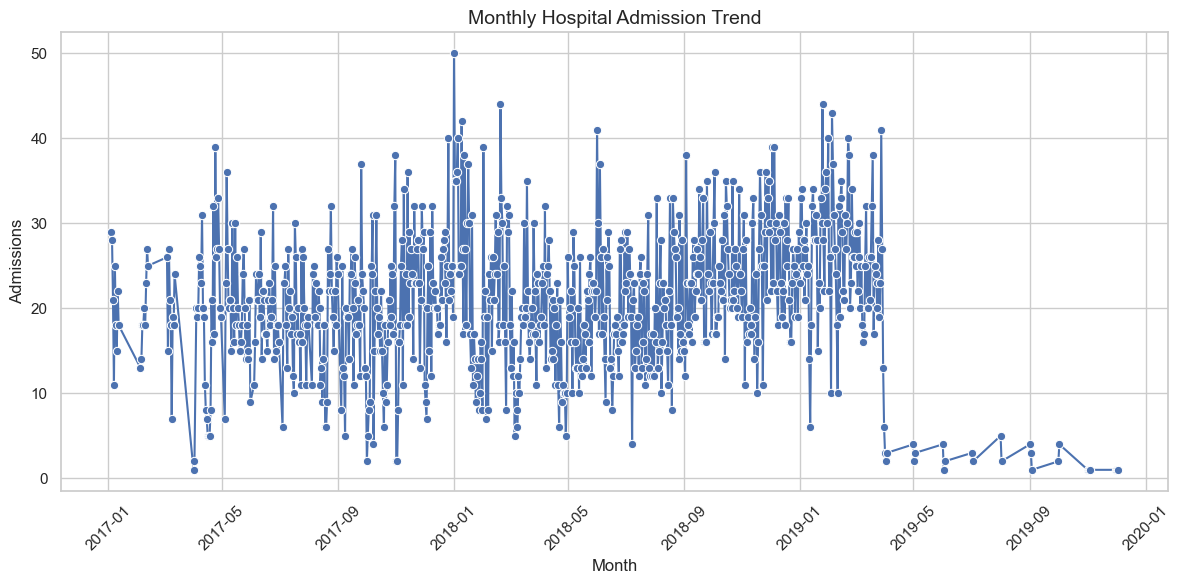

In [19]:
plt.figure(figsize=(12,6))
monthly = df.groupby("admission_date", as_index=False).size().rename(
    columns={"size" : "admissions"}
).sort_values("admission_date")

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly, x='admission_date', y='admissions', marker='o')
plt.title('Monthly Hospital Admission Trend', fontsize=14)
plt.xlabel("Month")
plt.ylabel("Admissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

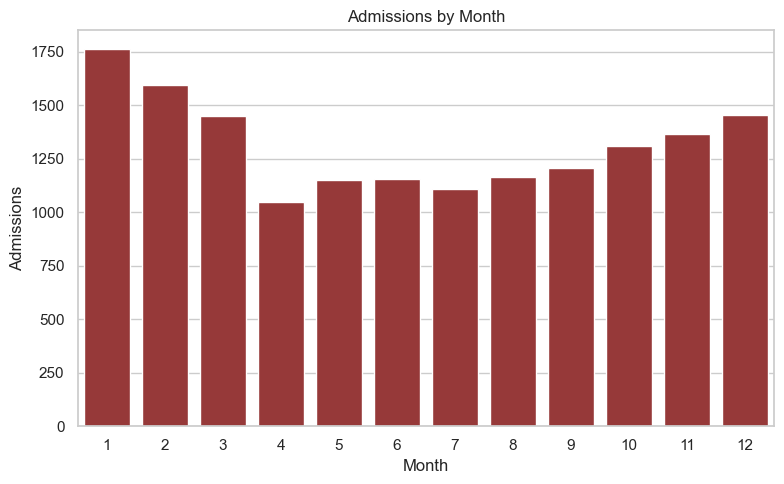

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(x="month", y="admissions",
            data=df.groupby("month").size().reset_index(name="admissions"), color='brown')
plt.title("Admissions by Month")
plt.xlabel("Month")
plt.ylabel("Admissions")
plt.tight_layout()
plt.show()

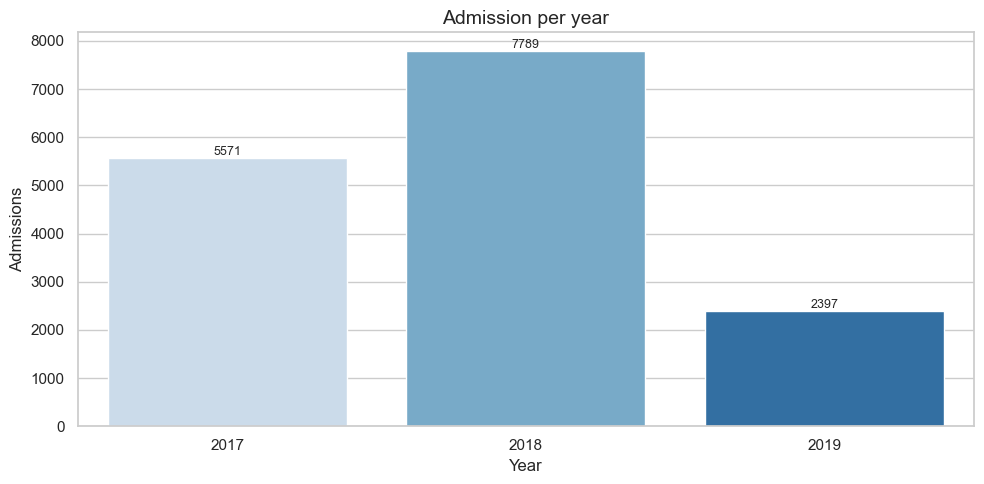

In [21]:
year_order = sorted(df['year'].unique())
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x='year', order=year_order,palette='Blues')
ax.set_title("Admission per year", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Admissions")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
               (p.get_x() + p.get_width() / 2, p.get_height()),
               ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

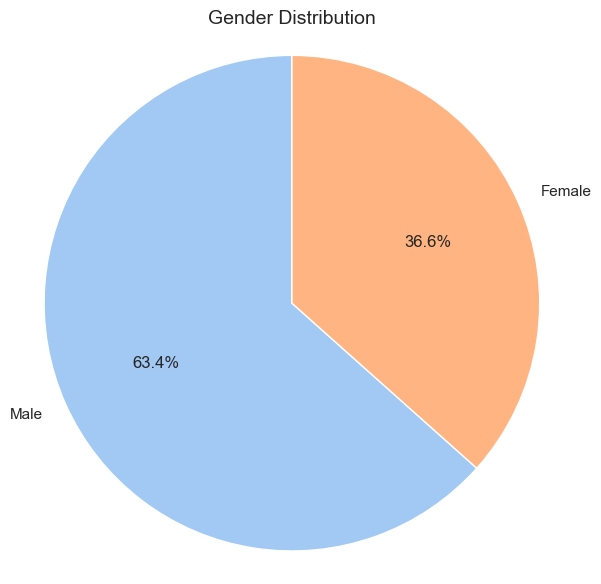

In [22]:
gender_count = df['gender'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(gender_count, labels=['Male', 'Female'],autopct='%1.1f%%',
       startangle=90, colors=sns.color_palette("pastel"))
plt.title("Gender Distribution", fontsize=14)
plt.axis("equal")
plt.tight_layout()
plt.show()

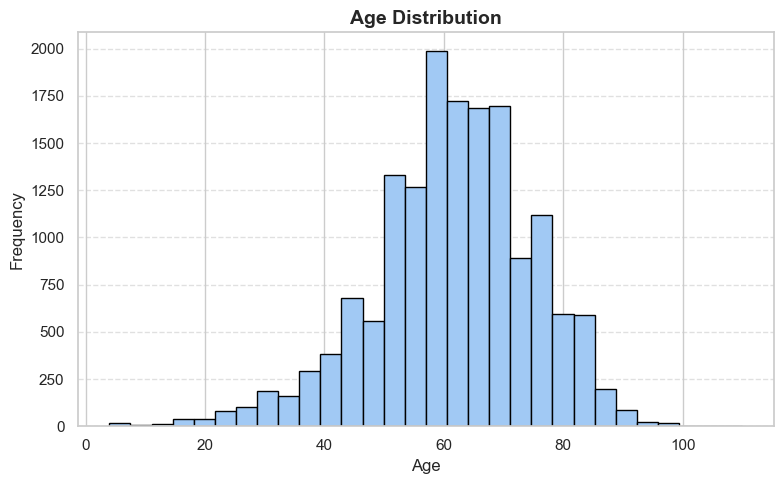

In [23]:
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=30, color=sns.color_palette('pastel')[0],
        edgecolor='black')
plt.title("Age Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

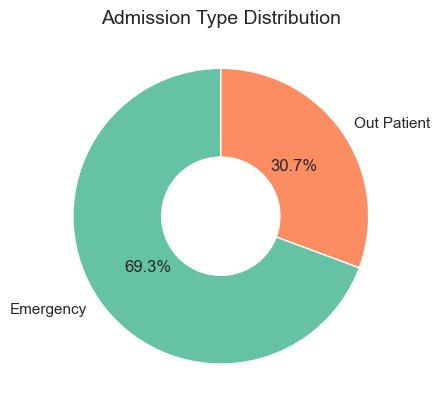

In [24]:
counts = df["admission_type"].value_counts()

counts = df['admission_type'].value_counts()
plt.pie(counts, labels=['Emergency', 'Out Patient'], autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("Set2"), wedgeprops=dict(width=0.6))
plt.title("Admission Type Distribution", fontsize=14)
plt.show()

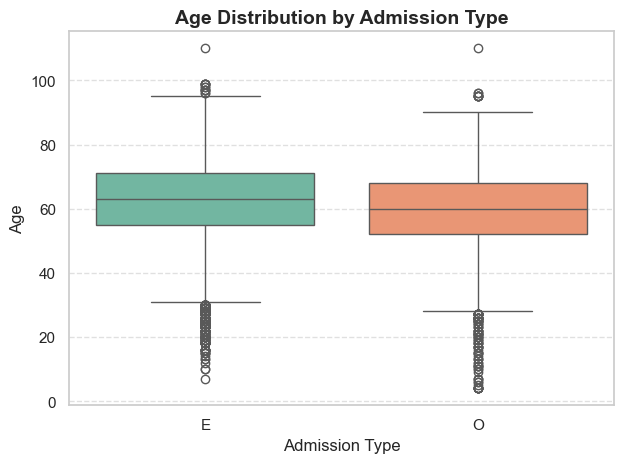

In [25]:
sns.boxplot(x='admission_type', y='age', data=df, 
           palette='Set2',)
plt.title("Age Distribution by Admission Type", fontsize=14, fontweight="bold")
plt.xlabel("Admission Type", fontsize=12)
plt.ylabel("Age", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [26]:
df['length_of_stay'].max()

98

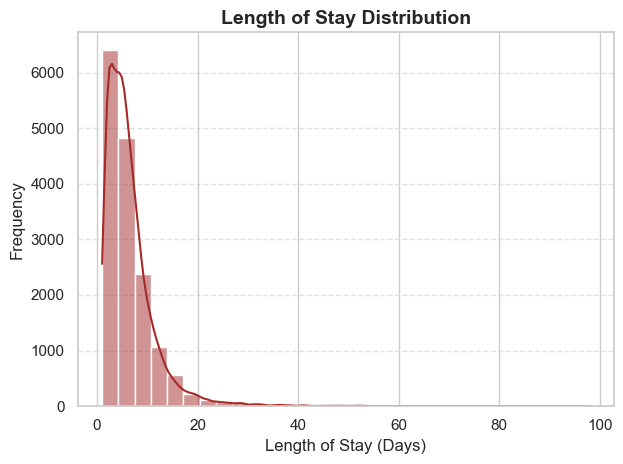

In [27]:
sns.histplot(data=df, x='length_of_stay', bins=30, kde=True, color='brown')
plt.title("Length of Stay Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Length of Stay (Days)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

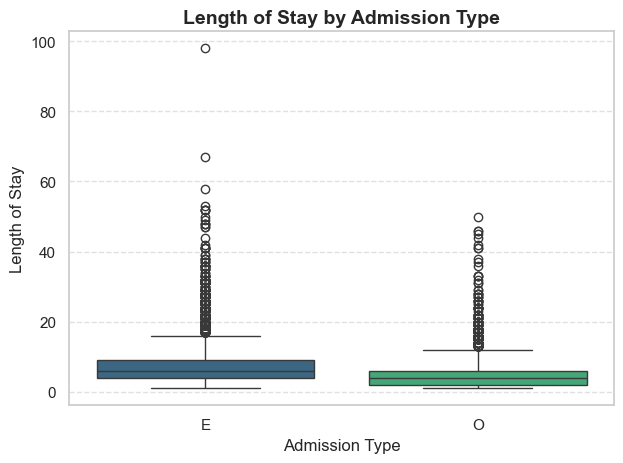

In [28]:
sns.boxplot(x='admission_type', y='length_of_stay', data=df, 
           palette='viridis',)
plt.title("Length of Stay by Admission Type", fontsize=14, fontweight="bold")
plt.xlabel("Admission Type", fontsize=12)
plt.ylabel("Length of Stay", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

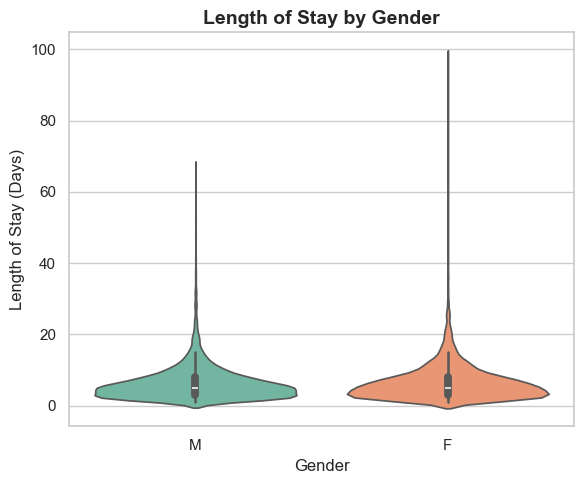

In [29]:
plt.figure(figsize=(6,5))
sns.violinplot(x="gender", y="length_of_stay", data=df, palette="Set2")
plt.title("Length of Stay by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Length of Stay (Days)")
plt.tight_layout()
plt.show()


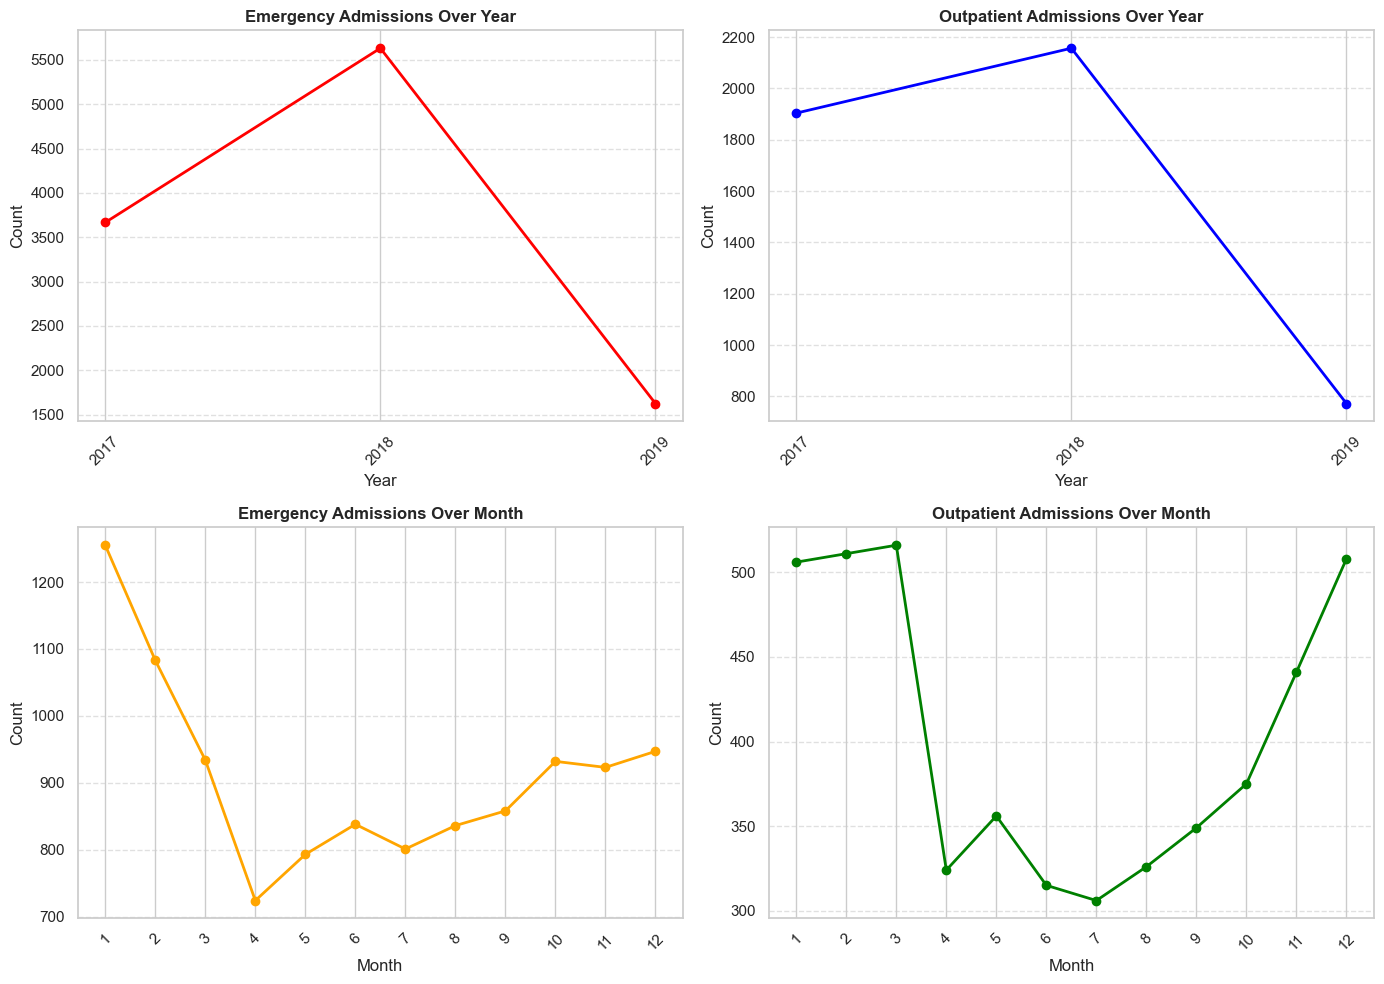

In [30]:
plt.figure(figsize=(14,10))


plt.subplot(2,2,1)
emergency = df[df['admission_type'] == 'E']
em_yearly = emergency.groupby("year").size().reset_index(name='count')
plt.plot(em_yearly['year'].astype(str), em_yearly['count'], marker='o', color='red', linewidth=2)
plt.xticks(rotation=45)
plt.title("Emergency Admissions Over Year", fontsize=12, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.subplot(2,2,2)
outpatient = df[df['admission_type'] == 'O']
out_yearly = outpatient.groupby("year").size().reset_index(name='count')
plt.plot(out_yearly['year'].astype(str), out_yearly['count'], marker='o', color='blue', linewidth=2)
plt.xticks(rotation=45)
plt.title("Outpatient Admissions Over Year", fontsize=12, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.subplot(2,2,3)
em_monthly = emergency.groupby("month").size().reset_index(name='count')
plt.plot(em_monthly['month'].astype(str), em_monthly['count'], marker='o', color='orange', linewidth=2)
plt.xticks(rotation=45)
plt.title("Emergency Admissions Over Month", fontsize=12, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.subplot(2,2,4)
out_monthly = outpatient.groupby("month").size().reset_index(name='count')
plt.plot(out_monthly['month'].astype(str), out_monthly['count'], marker='o', color='green', linewidth=2)
plt.xticks(rotation=45)
plt.title("Outpatient Admissions Over Month", fontsize=12, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

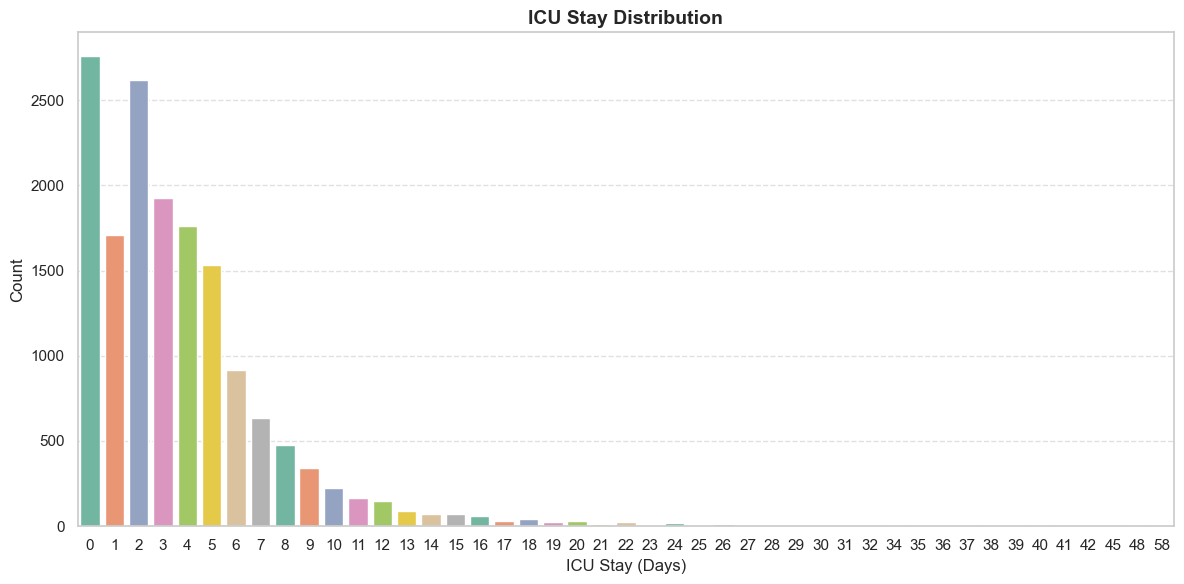

In [31]:
plt.figure(figsize=(12,6))
sns.countplot(x='icu_stay_days', data=df, palette='Set2', 
             order=sorted(df['icu_stay_days'].unique()))
plt.title("ICU Stay Distribution", fontsize=14, fontweight="bold")
plt.xlabel("ICU Stay (Days)")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

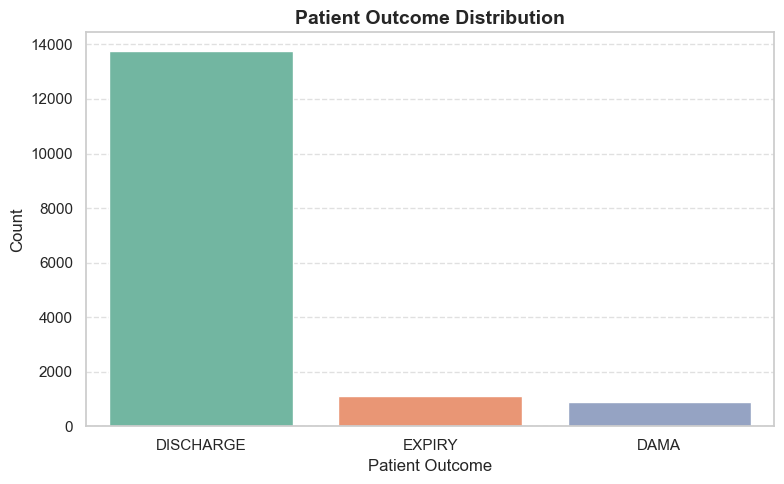

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(x="patient_outcome",data=df,palette="Set2",order=df["patient_outcome"].value_counts().index )
plt.title("Patient Outcome Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Patient Outcome", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

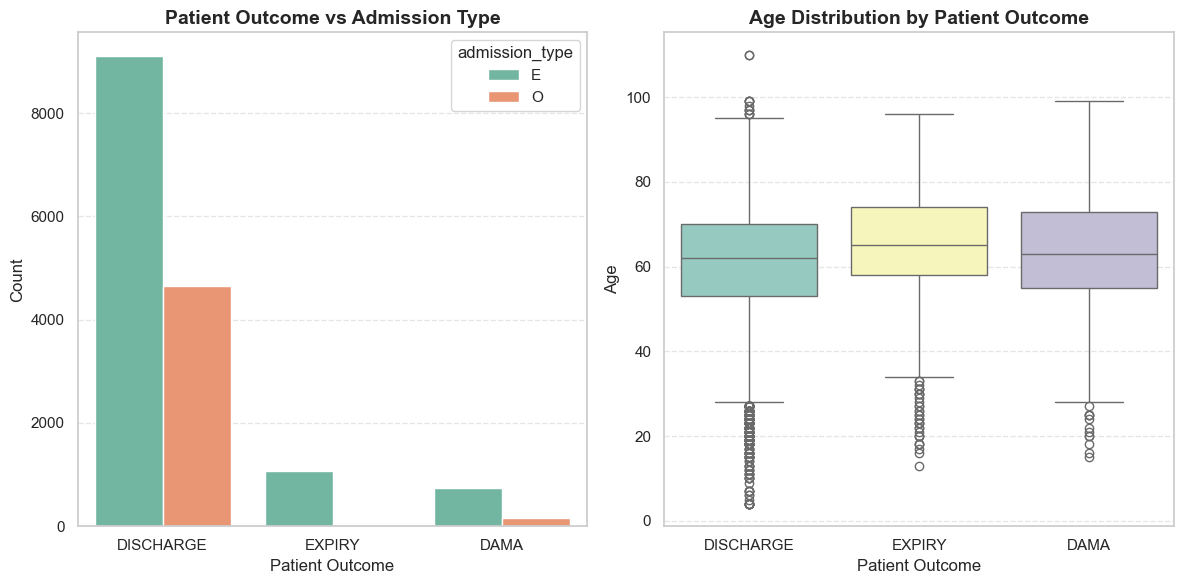

In [33]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.countplot(x="patient_outcome",hue="admission_type",data=df,palette="Set2",order=df["patient_outcome"].value_counts().index)
plt.title("Patient Outcome vs Admission Type", fontsize=14, fontweight="bold")
plt.xlabel("Patient Outcome", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)


plt.subplot(1,2,2)
sns.boxplot(x="patient_outcome",y="age",data=df,palette="Set3",)
plt.title("Age Distribution by Patient Outcome", fontsize=14, fontweight="bold")
plt.xlabel("Patient Outcome", fontsize=12)
plt.ylabel("Age", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

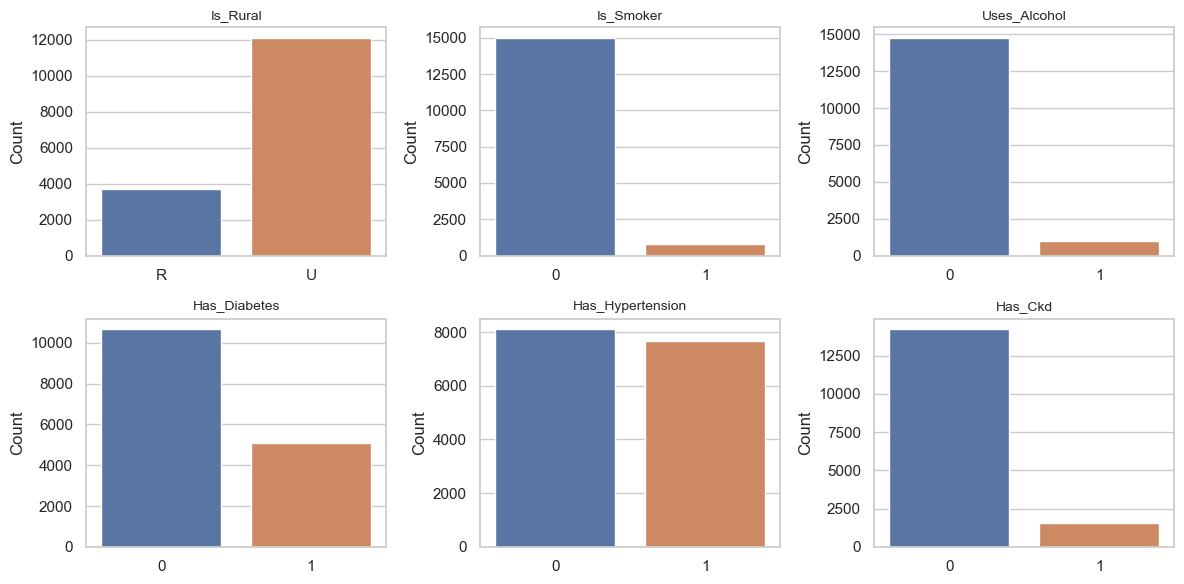

In [34]:
cols1 = ["is_rural", "is_smoker", "uses_alcohol", "has_diabetes",
        "has_hypertension","has_ckd"]
cols2 = ["has_heart_failure",
        "has_acs", "has_shock", "has_chest_infection"]

plt.figure(figsize=(12,6))
for i, col in enumerate(cols1, 1):
    plt.subplot(2,3,i)
    sns.countplot(x=col, data=df, palette='deep')
    plt.title(col.replace("-"," ").title(), fontsize=10)
    plt.xlabel('')
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

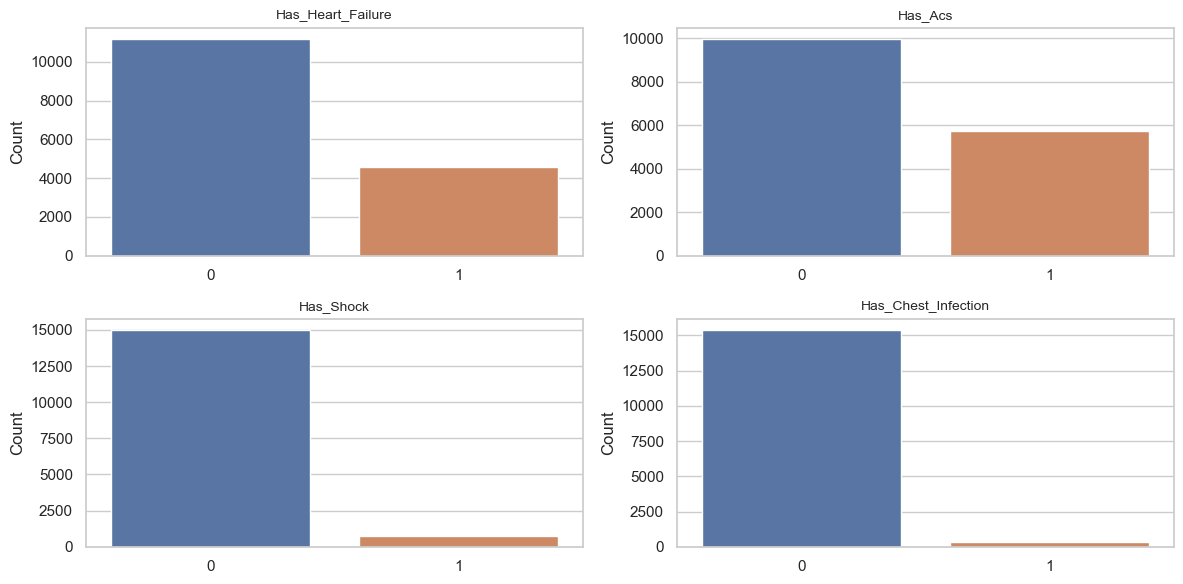

In [35]:
plt.figure(figsize=(12,6))
for i, col in enumerate(cols2, 1):
    plt.subplot(2,2,i)
    sns.countplot(x=col, data=df, palette='deep')
    plt.title(col.replace("-"," ").title(), fontsize=10)
    plt.xlabel('')
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

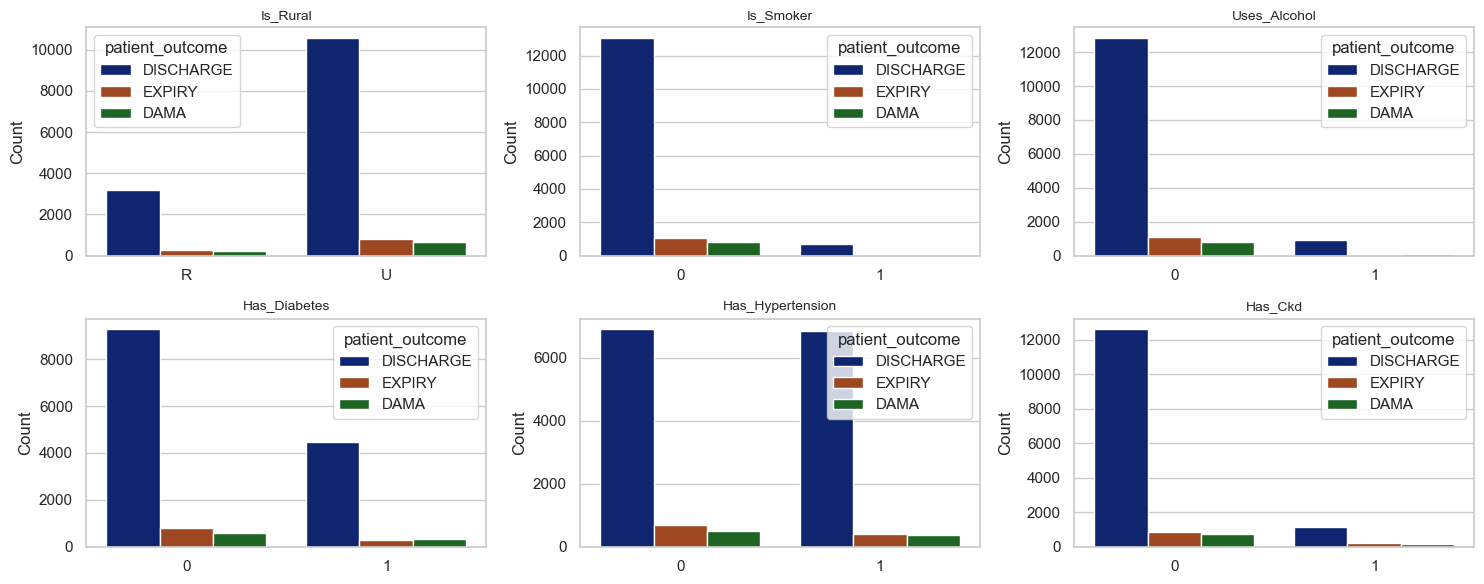

In [36]:
plt.figure(figsize=(15,6))
for i, col in enumerate(cols1, 1):
    plt.subplot(2,3,i)
    sns.countplot(x=col, data=df,hue='patient_outcome',palette='dark')
    plt.title(col.replace("-"," ").title(), fontsize=10)
    plt.xlabel('')
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

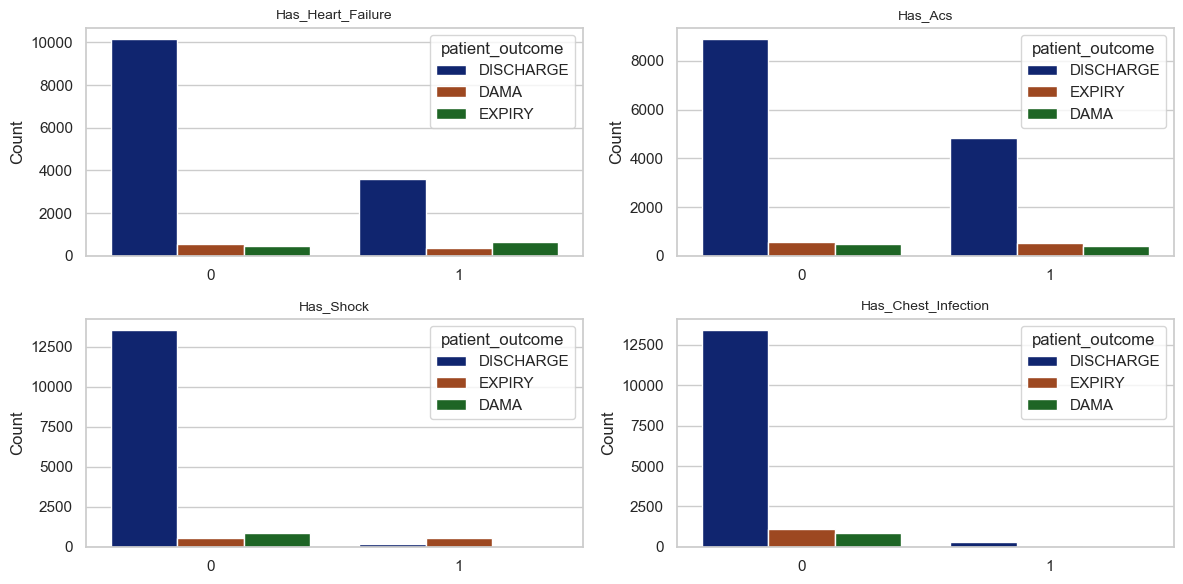

In [37]:
plt.figure(figsize=(12,6))
for i, col in enumerate(cols2, 1):
    plt.subplot(2,2,i)
    sns.countplot(x=col, data=df,hue='patient_outcome',palette='dark')
    plt.title(col.replace("-"," ").title(), fontsize=10)
    plt.xlabel('')
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [38]:
df['patient_outcome'].value_counts()

patient_outcome
DISCHARGE    13756
EXPIRY        1105
DAMA           896
Name: count, dtype: int64

In [39]:
df['gender'] = df['gender'].map({'M' : 1, 'F':0})
df['is_rural'] = df['is_rural'].map({'U' : 0, 'R':1})
df['admission_type'] = df['admission_type'].map({'E' : 1, 'O':0})
df['patient_outcome'] = df['patient_outcome'].map({'EXPIRY' : 0, 'DISCHARGE':1,
                                                  'DAMA':2})

In [40]:
df.head()

,admission_date,age,gender,is_rural,admission_type,length_of_stay,icu_stay_days,patient_outcome,is_smoker,uses_alcohol,has_diabetes,has_hypertension,has_ckd,has_heart_failure,has_acs,has_shock,has_chest_infection,month,year
0,2017-01-04,81,1,1,1,3,2,1,0,0,1,0,0,1,1,0,0,1,2017
1,2017-01-04,65,1,1,1,5,2,1,0,1,0,1,0,0,0,0,0,1,2017
2,2017-01-04,53,1,0,1,3,3,1,0,0,1,0,0,1,0,0,0,1,2017
3,2017-01-04,67,0,0,1,8,6,1,0,0,0,1,0,0,0,0,0,1,2017
4,2017-01-04,60,0,0,1,23,9,1,0,0,0,1,0,0,0,0,0,1,2017


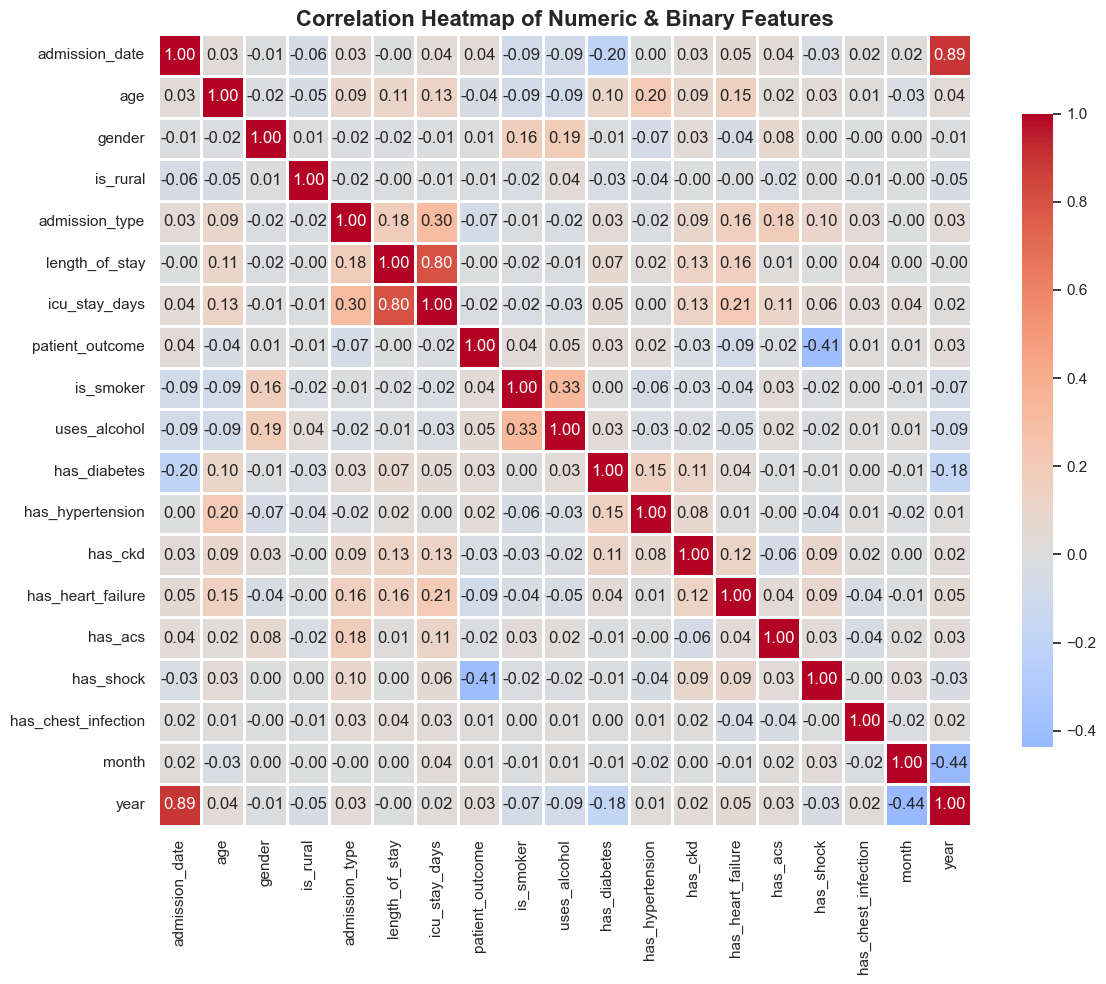

In [41]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0,linewidths=1,linecolor="white",cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Numeric & Binary Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [42]:
df['length_of_stay'].max()

98

In [43]:
def categorize_los(days):
    if days < 3:
        return 'Short'
    elif days <= 10:
        return 'Medium'
    else:
        return 'Long'

df['los_category'] = df['length_of_stay'].apply(categorize_los)

# Length of Stay Prediction 

In [44]:
x = df[['age', 'gender', 'is_rural', 'admission_type',
        'is_smoker', 'uses_alcohol', 'has_diabetes', 'has_hypertension',
        'has_ckd', 'has_heart_failure', 'has_acs', 'has_shock', 
        'has_chest_infection', 'month', 'year']]
y = df['los_category']

In [45]:
rf = RandomForestClassifier(n_estimators=500, random_state=42, max_depth=None)
rf.fit(x, y)

RandomForestClassifier(n_estimators=500, random_state=42)

In [46]:
feat_imp = pd.Series(rf.feature_importances_, index=x.columns).sort_values(ascending=False)
print(feat_imp)

age                    0.456025
month                  0.226343
year                   0.055477
has_hypertension       0.035796
is_rural               0.033025
gender                 0.031422
has_diabetes           0.025593
admission_type         0.024535
has_acs                0.023954
has_heart_failure      0.022261
has_shock              0.016585
has_ckd                0.015837
uses_alcohol           0.013968
is_smoker              0.011691
has_chest_infection    0.007488
dtype: float64


In [47]:
X = df[['age', 'month', 'year', 'gender', 'is_rural', 'admission_type', 
        'has_hypertension', 'has_acs', 'has_diabetes']]

In [48]:
le = LabelEncoder()
y = le.fit_transform(df['los_category'])

In [49]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [50]:
xgb_clf = XGBClassifier(n_estimators=500,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,random_state=42,
                        use_label_encoder=False,eval_metric='mlogloss')
xgb_clf.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [51]:
y_pred = xgb_clf.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.68

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.03      0.06       430
           1       0.70      0.96      0.81      2184
           2       0.34      0.06      0.10       538

    accuracy                           0.68      3152
   macro avg       0.45      0.35      0.32      3152
weighted avg       0.58      0.68      0.59      3152



In [52]:
joblib.dump(xgb_clf, "length_of_stay.pkl")

['length_of_stay.pkl']

# Emergency Admission Classification

In [53]:
df.head(2)

,admission_date,age,gender,is_rural,admission_type,length_of_stay,icu_stay_days,patient_outcome,is_smoker,uses_alcohol,has_diabetes,has_hypertension,has_ckd,has_heart_failure,has_acs,has_shock,has_chest_infection,month,year,los_category
0,2017-01-04,81,1,1,1,3,2,1,0,0,1,0,0,1,1,0,0,1,2017,Medium
1,2017-01-04,65,1,1,1,5,2,1,0,1,0,1,0,0,0,0,0,1,2017,Medium


In [54]:
df['is_emergency'] = (df['admission_type']==1)

In [55]:
x = df[['age', 'gender', 'is_rural', 'admission_type',
        'is_smoker', 'uses_alcohol', 'has_diabetes', 'has_hypertension',
        'has_ckd', 'has_heart_failure', 'has_acs', 'has_shock', 
        'has_chest_infection', 'month', 'year']]
y = df['is_emergency']

In [56]:
rf = RandomForestClassifier(n_estimators=500, random_state=42, max_depth=None)
rf.fit(x, y)

feat_imp = pd.Series(rf.feature_importances_, index=x.columns).sort_values(ascending=False)
print(feat_imp)

admission_type         0.933022
has_acs                0.016293
age                    0.015056
has_heart_failure      0.010850
month                  0.006595
has_shock              0.003701
has_ckd                0.003402
year                   0.002870
has_hypertension       0.001538
gender                 0.001457
has_diabetes           0.001386
is_rural               0.001315
has_chest_infection    0.000917
uses_alcohol           0.000862
is_smoker              0.000736
dtype: float64


In [57]:
X = df[['age', 'gender', 'has_heart_failure', 'has_acs', 'has_shock', 'has_ckd', 
        'has_hypertension', 'has_diabetes', 'has_chest_infection','month','year']]
y = df['is_emergency']

In [58]:
x_train, x_test, y_train,y_test = train_test_split(x,y,test_size=0.2)

In [59]:
en_model = LogisticRegression(C=0.5,solver="liblinear",max_iter=1000,random_state=42)
en_model.fit(x_train, y_train)


LogisticRegression(C=0.5, max_iter=1000, random_state=42, solver='liblinear')

In [60]:
pred = en_model.predict(x_test)

In [61]:
scores = cross_val_score(en_model, X, y, cv=5)
print(scores, scores.mean())

[0.69257614 0.67480964 0.67914948 0.69120914 0.6883529 ] 0.6852194613908726


In [62]:
joblib.dump(en_model,"emergency_admission.pkl")

['emergency_admission.pkl']

# ICU REQUIREMENT CLASSIFICATION

In [63]:
df.head(2)

,admission_date,age,gender,is_rural,admission_type,length_of_stay,icu_stay_days,patient_outcome,is_smoker,uses_alcohol,has_diabetes,has_hypertension,has_ckd,has_heart_failure,has_acs,has_shock,has_chest_infection,month,year,los_category,is_emergency
0,2017-01-04,81,1,1,1,3,2,1,0,0,1,0,0,1,1,0,0,1,2017,Medium,True
1,2017-01-04,65,1,1,1,5,2,1,0,1,0,1,0,0,0,0,0,1,2017,Medium,True


In [64]:
x = df[['age', 'gender', 'is_rural', 'admission_type',
        'is_smoker', 'uses_alcohol', 'has_diabetes', 'has_hypertension',
        'has_ckd', 'has_heart_failure', 'has_acs', 'has_shock', 
        'has_chest_infection', 'month', 'year']]
y = df['icu_stay_days']

rf = RandomForestClassifier(n_estimators=500, random_state=42, max_depth=None)
rf.fit(x, y)

feat_imp = pd.Series(rf.feature_importances_, index=x.columns).sort_values(ascending=False)
print(feat_imp)

age                    0.443230
month                  0.219780
admission_type         0.045282
year                   0.044283
has_hypertension       0.039733
gender                 0.035697
is_rural               0.035207
has_diabetes           0.034863
has_heart_failure      0.019597
has_acs                0.019163
has_ckd                0.015804
uses_alcohol           0.014198
is_smoker              0.013064
has_shock              0.011676
has_chest_infection    0.008423
dtype: float64


In [65]:
df["icu_required"] = (df["icu_stay_days"] > 0).astype(int)

In [66]:
x = df[['age', 'gender', 'is_rural', 'admission_type',
        'has_diabetes', 'has_hypertension',
         'has_heart_failure', 'has_acs','month', 'year']]
y = df['icu_required']

In [67]:
x_train, x_test, y_train,y_test = train_test_split(x,y,test_size=0.2)

In [68]:
icu_model = LogisticRegression(C=0.5,solver="liblinear",max_iter=1000,random_state=42)
icu_model.fit(x_train, y_train)

LogisticRegression(C=0.5, max_iter=1000, random_state=42, solver='liblinear')

In [69]:
pred = icu_model.predict(x_test)

In [70]:
scores = cross_val_score(icu_model, X, y, cv=5)
print(scores, scores.mean())

[0.8248731  0.82455584 0.82481752 0.8241828  0.82481752] 0.8246493539235793


In [71]:
joblib.dump(icu_model,"icu_requirement.pkl")

['icu_requirement.pkl']

# PATIENT OUTCOME PREDICTION (OPTIONAL & RESPONSIBLE)

In [72]:
df.head()

,admission_date,age,gender,is_rural,admission_type,length_of_stay,icu_stay_days,patient_outcome,is_smoker,uses_alcohol,has_diabetes,has_hypertension,has_ckd,has_heart_failure,has_acs,has_shock,has_chest_infection,month,year,los_category,is_emergency,icu_required
0,2017-01-04,81,1,1,1,3,2,1,0,0,1,0,0,1,1,0,0,1,2017,Medium,True,1
1,2017-01-04,65,1,1,1,5,2,1,0,1,0,1,0,0,0,0,0,1,2017,Medium,True,1
2,2017-01-04,53,1,0,1,3,3,1,0,0,1,0,0,1,0,0,0,1,2017,Medium,True,1
3,2017-01-04,67,0,0,1,8,6,1,0,0,0,1,0,0,0,0,0,1,2017,Medium,True,1
4,2017-01-04,60,0,0,1,23,9,1,0,0,0,1,0,0,0,0,0,1,2017,Long,True,1


In [73]:
x = df[['age', 'gender', 'is_rural', 'admission_type',
        'is_smoker', 'uses_alcohol', 'has_diabetes', 'has_hypertension',
        'has_ckd', 'has_heart_failure', 'has_acs', 'has_shock', 
        'has_chest_infection', 'month', 'year']]
y = df['patient_outcome']

rf = RandomForestClassifier(n_estimators=500, random_state=42, max_depth=None)
rf.fit(x, y)

feat_imp = pd.Series(rf.feature_importances_, index=x.columns).sort_values(ascending=False)
print(feat_imp)

age                    0.356000
month                  0.181890
has_shock              0.169809
year                   0.053527
gender                 0.031376
is_rural               0.030152
has_diabetes           0.029823
has_heart_failure      0.027985
admission_type         0.025617
has_acs                0.024715
has_hypertension       0.023624
has_ckd                0.019199
uses_alcohol           0.010522
is_smoker              0.009154
has_chest_infection    0.006607
dtype: float64


In [74]:
df['outcome_enc'] = (df['patient_outcome'] ==1).astype(int)
x = df[['age', 'gender', 'is_rural', 'admission_type','has_diabetes', 'has_hypertension',
        'has_heart_failure', 'has_acs', 'has_shock','month', 'year']]
y = df['outcome_enc']

In [75]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [76]:
out_model = LogisticRegression(C=0.5,solver="liblinear",max_iter=1000,random_state=42)
out_model.fit(x_train, y_train)

LogisticRegression(C=0.5, max_iter=1000, random_state=42, solver='liblinear')

In [77]:
pred = out_model.predict(x_test)

In [78]:
scores = cross_val_score(out_model, x, y, cv=5)
print(scores, scores.mean())

[0.90133249 0.89498731 0.9003491  0.8987623  0.8987623 ] 0.8988386975692191


In [79]:
joblib.dump(out_model,"patient_outcome.pkl")

['patient_outcome.pkl']